<a href="https://colab.research.google.com/github/yashpotey/assignment-01-bitsom_ba_2511080/blob/main/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler delivered a fast yorker to take the wicket",
    "India won the cricket match by chasing a huge target",
    "The fielders saved crucial runs near the boundary",

    # Cooking (3)
    "Add spices and cook the vegetables on low heat",
    "The recipe requires baking the cake for 30 minutes",
    "Chop the onions finely before frying them in oil",

    # Cybersecurity (3)
    "Strong passwords help protect against cyber attacks",
    "Encryption ensures secure communication over networks",
    "Phishing attacks trick users into revealing sensitive information"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
# cosine similarity
similarity_matrix = np.inner(embeddings, embeddings)

print(similarity_matrix.shape)  # should be (10, 10)

(10, 10)


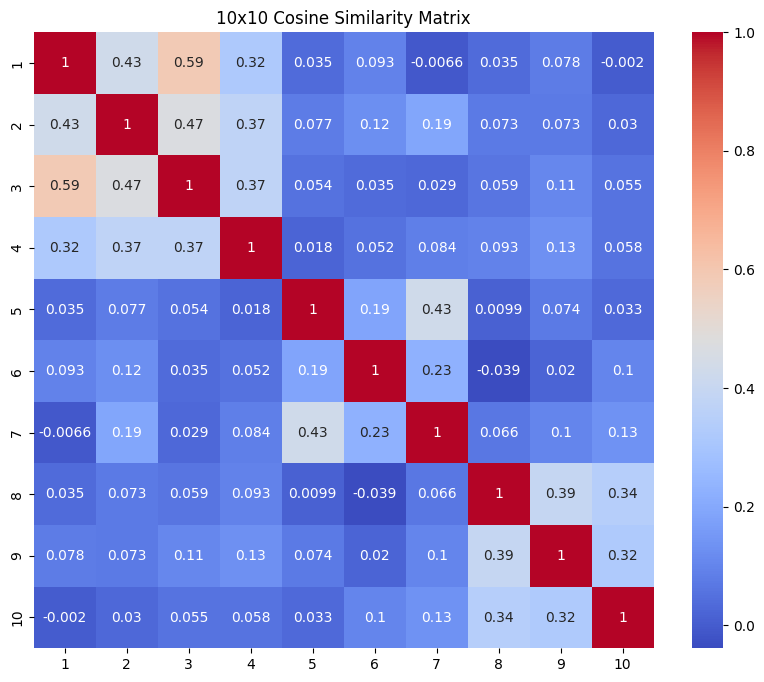

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm",
            xticklabels=range(1,11),
            yticklabels=range(1,11))
plt.title("10x10 Cosine Similarity Matrix")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])[0]

# compute similarity with all sentences
scores = np.inner(embeddings, query_embedding)

# get top 2 indices
top_indices = np.argsort(scores)[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {scores[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The bowler delivered a fast yorker to take the wicket
Similarity Score: 0.6663

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

